# 3D rotational Brownian motion: angle PDFs — LAMMPS vs analytical formulas

This notebook compares **single-step PDFs** (probability density functions) computed with LAMMPS using the conventional **Euler+projection method** and a novel **geometric integrator** against **analytical results** for **three-dimensional (3D)** rotational Brownian motion (RBM) on the unit **sphere** (3D RBM; orientation space $S^2$).

The one-step PDF $p(\vartheta;\Delta t)$ depends on the relative angle $\vartheta\in[0,\pi]$ and, for free rotational diffusion, on the dimensionless product $D_R\Delta t$, that is, not on $D_R$ and $\Delta t$ separately, where $D_R$ is the rotational diffusion constant and $\Delta t$ the timestep. Let $\mathbf{u}(t)$ denote the particle’s unit orientation at time $t$. The single-step relative angle is $\vartheta=\arccos(\mathbf{u}(t+\Delta t)\cdot\mathbf{u}(t))$, that is, the rotation angle accumulated during one timestep $\Delta t$. Owing to stationarity of rotational Brownian motion, this single-step distribution is identical to the distribution of the angle between $\mathbf{u}(t)$ and $\mathbf{u}(0)$ at time $t=\Delta t$.

**Technical details**, the main **analytical formulas** and **key observations** are summarized below; for details see the reference.

**Reference:**  
Felix Höfling & Arthur V. Straube, *Phys. Rev. Research* **7**, 043034 (2025)  
open access, doi:[10.1103/wzdn-29p4](https://doi.org/10.1103/wzdn-29p4)

## Technical details

We load precomputed `.dat` files from:

- LAMMPS numerics (markers): `data/pdf_lammps_sphere_{projection,geometric}_Dr<Dr>_dt<dt>.dat`
- Analytics (lines): `data/pdf_theory_sphere_{exact,projection,geometric}_Dr<Dr>_dt<dt>.dat`

created by:

- `scripts/compute_pdf_from_angles.py` (LAMMPS numerics)
- `scripts/compute_pdf_from_theory.py` (analytic expressions for PDFs from theory)

Since the theory depends on the product $D_R\Delta t$, we fix $D_R$ and vary the timestep $\Delta t$ in the numerical comparisons; thus smaller (larger) timestep below refers to smaller (larger) values of $D_R\Delta t$.

We plot the rescaled angle $x=\vartheta/\pi$ on the horizontal axis and the one-step PDF $p(\vartheta;\Delta t)$ on the vertical axis.  
Notation in code: `theta` $\leftrightarrow \vartheta$, `Dr` $\leftrightarrow D_R$.

## Analytical formulas (3D/sphere)

**Exact (Eq. 38)**  (here, $P_\ell$ is the Legendre polynomial of degree $\ell$):
$$
p_{\mathrm{exact}}(\vartheta;\Delta t)=\tfrac12 \sin\vartheta\sum_{\ell=0}^{\infty}(2\ell+1)P_\ell(\cos\vartheta)\,{\mathrm e}^{-\ell(\ell+1)D_R\Delta t}
$$

**Geometric scheme (Eq. 41):**
$$
p_{\mathrm{geom}}(\vartheta;\Delta t) = \sum_{k=0}^{\infty}\frac{\vartheta+2\pi k}{2D_R\Delta t}{\mathrm e}^{-(\vartheta+2\pi k)^2/(4D_R\Delta t)}
+\sum_{k=1}^{\infty}\frac{2\pi k-\vartheta}{2D_R\Delta t}{\mathrm e}^{-(2\pi k-\vartheta)^2/(4D_R\Delta t)}
$$
Note: For most practical purposes (if $D_R\Delta t$ not extremely large), it is sufficient to restrict the sum to the $k = 0$ term such that
$$p_{\mathrm{geom}}(\vartheta;\Delta t) \approx \frac{\vartheta}{2D_R\Delta t}{\mathrm e}^{-\vartheta^2/(4D_R\Delta t)}.$$
The next-to-leading order term ($k = 1$) is suppressed by a factor of $\exp(−\pi^2/4 D_R \Delta t)$.

**Euler + projection scheme (Eq. 44):**  
For $0\le\vartheta<\pi/2$,
$$
p_{\mathrm{proj}}(\vartheta;\Delta t)=
\frac{\sin\vartheta}{2D_R\Delta t\cos^3\vartheta}\exp\!\left[-\frac{\cos^{-2}\vartheta-1}{4D_R\Delta t}\right]
$$
and $p_{\mathrm{proj}}(\vartheta;\Delta t)=0$ for $\pi/2\le\vartheta\le\pi$.

In practice we truncate the sums at finite $\ell_\max$ and $k_\max$; see the python script.


## Observations

- For sufficiently small timesteps $\Delta t$ (at fixed $D_R$), the PDFs obtained with both the Euler+projection and geometric integrators agree well with the exact analytical one-step PDF over the full range of $\vartheta$.
- The Euler+projection scheme exhibits the characteristic cutoff at $\vartheta=\pi/2$ (finite support), consistent with Eq. (44); this is, however, in qualitative disagreement with the exact solution.
- As $\Delta t$ is increased, the Euler+projection PDF deviates significantly from the analytical result, whereas the geometric integrator remains qualitatively consistent and quantitatively close to the analytical PDF even at comparatively large timesteps.

Recall that from theory the one-step PDF depends only on $D_R\Delta t$; here we fix $D_R$ and vary $\Delta t$ to probe timestep effects.

## Implementation
The following helper functions are shared between the sphere (3D RBM) and circle (2D RBM) notebooks to avoid duplicated code (click to inspect).
- I/O + formatting: [rbm/io.py](../rbm/io.py)
- Plot helper: [rbm/plot.py](../rbm/plot.py)



In [13]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

# --- paths ---
repo_root = Path("..").resolve()
data_dir = repo_root / "data"
figs_dir = repo_root / "figs"
figs_dir.mkdir(exist_ok=True)

# --- allow importing internal helpers from /rbm ---
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from rbm import fmt_float
from rbm.plot import plot_compare_pdf


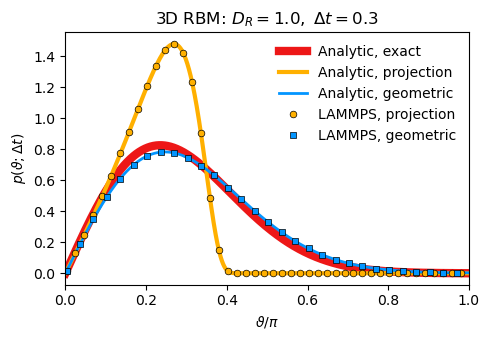

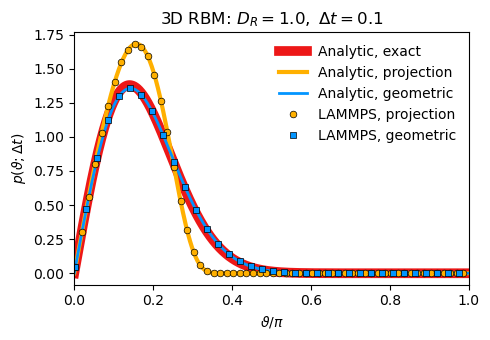

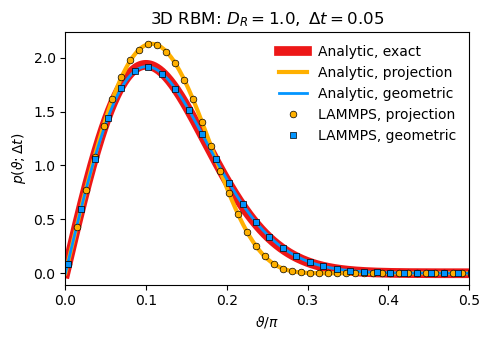

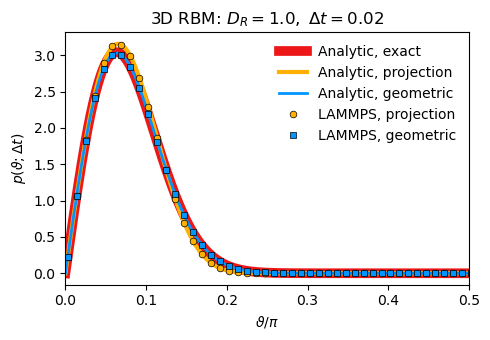

In [14]:
# Make few plots to compare PDFs at different timesteps

manifold = "sphere"       # 3D RBM
Dr = 1.0                  # rotational diffusion constant
title_prefix = "3D RBM"   # used in figure title

# Per-figure settings (kept from the original notebook)
plot_specs = [
    dict(dt=0.3,  xlim=(0, 1),   step_proj=4, step_geom=6, lw_exact=6.0),
    dict(dt=0.1,  xlim=(0, 1),   step_proj=3, step_geom=5),
    dict(dt=0.05, xlim=(0, 0.5), step_proj=2, step_geom=3),
    dict(dt=0.02, xlim=(0, 0.5), step_proj=2, step_geom=2),
]

for spec in plot_specs:
    dt = spec["dt"]

    fig, ax = plt.subplots(figsize=(5, 3.5))

    # Forward any per-plot overrides (xlim, step_* and optionally lw_exact, etc.)
    plot_compare_pdf(
        ax,
        manifold=manifold,
        data_dir=data_dir,
        Dr=Dr,
        dt=dt,
        **{k: v for k, v in spec.items() if k != "dt"},
    )

    ax.set_title(fr"{title_prefix}: $D_R={fmt_float(Dr)},\ \Delta t={fmt_float(dt)}$")

    fig.tight_layout()

    # Systematic filenames, identical to the old naming scheme but generated automatically
    base = f"compare_pdf_{manifold}_Dr{fmt_float(Dr)}_dt{fmt_float(dt)}"
    fig.savefig(figs_dir / f"{base}.png", dpi=300, bbox_inches="tight")
    fig.savefig(figs_dir / f"{base}.pdf", bbox_inches="tight")

    plt.show()
